# Inicio y Repaso
| Computer Vision - Clase práctica 1


## 1. Representación digital de imágenes

### ¿Cómo se representa una imagen?

Una imagen se representa como una **matriz** de n dimensiones, cada una representando un **canal** de la misma.

In [42]:
## carga de imagen
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('/content/avatar.png')

print(f"Tipo de imagen: {type(img)}")
print("-----------------------")
print(f"Dimensiones de imagen:{img.shape}")
print("-----------------------")
print(f"Matrices de imagen: {img}")


Tipo de imagen: <class 'numpy.ndarray'>
-----------------------
Dimensiones de imagen:(914, 1621, 3)
-----------------------
Matrices de imagen: [[[228 200 173]
  [228 200 173]
  [228 200 173]
  ...
  [207 166 131]
  [205 164 130]
  [212 171 137]]

 [[227 199 173]
  [227 200 173]
  [228 200 174]
  ...
  [207 166 132]
  [203 162 128]
  [211 170 135]]

 [[227 199 174]
  [228 200 175]
  [229 201 176]
  ...
  [206 165 130]
  [204 163 129]
  [204 163 129]]

 ...

 [[ 12  16  11]
  [  9  13   7]
  [ 18  22  17]
  ...
  [ 66  77  64]
  [ 66  78  65]
  [ 63  77  63]]

 [[ 11  15  10]
  [ 12  16  11]
  [ 25  29  24]
  ...
  [ 61  71  58]
  [ 60  72  59]
  [ 63  77  63]]

 [[  4   8   4]
  [ 14  18  13]
  [ 14  18  13]
  ...
  [ 62  73  60]
  [ 61  74  61]
  [ 66  79  66]]]


### Visualizacion de imagen

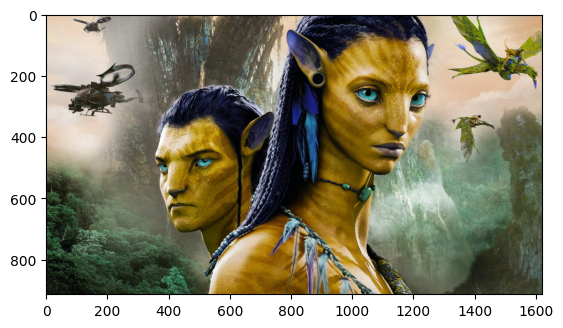

In [22]:
# Visualizar imagen
plt.imshow(img)
plt.show()

## 2. Espacios de color

Un modelo de color establece un conjunto de colores primarios a partir de los que, mediante mezclas, se pueden obtener otros colores hasta cubrir todo el espectro visible, además del propio blanco, negro y grises, y aún más.

Hay varios modelos de colores con los que podemos tratar una imagen.
Los mas comunes son:
- RGB
- CMYK
- HSV



Hya modelos sustractivos y aditivos, los primeros, obtienen coloress mediante las diferencias de colores de otros; los segundos, mediante la adición de colores.

### RGB

RGB representa la imagen con combinaciones de 3 canales: Rojo(R), Verde(G) y Azul (B).

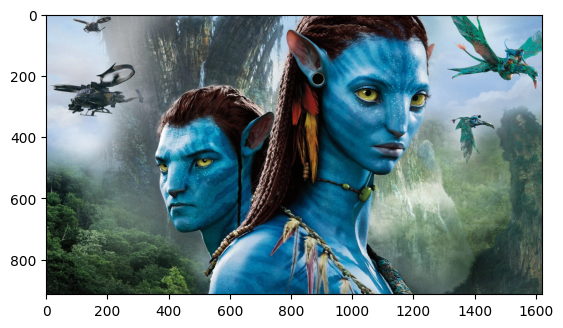

In [23]:
##### RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.show()

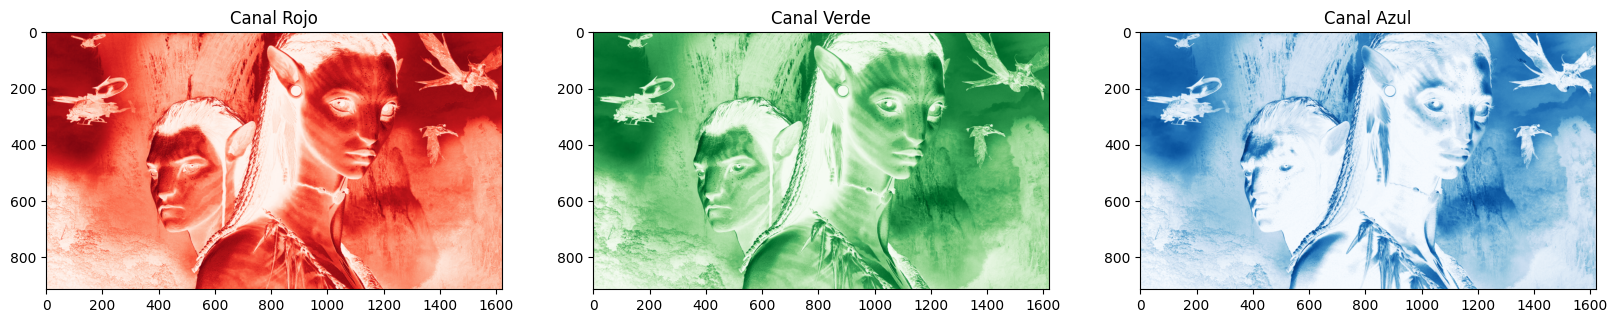

In [4]:
### Matrices separadas de RGB
fig, axs = plt.subplots(1, 3, figsize=(20, 15))
axs[0].imshow(img[:, :, 0], cmap='Reds')
axs[0].set_title('Canal Rojo')
axs[1].imshow(img[:, :, 1], cmap='Greens')
axs[1].set_title('Canal Verde')
axs[2].imshow(img[:, :, 2], cmap='Blues')
axs[2].set_title('Canal Azul')
plt.show()


### CMYK

Es un modelo sustractivo y se utiliza en impresión a partir de pigmentos de tres colores básicos: C – cian, M – magenta y Y – amarillo. La K viene del negro, ya que la combinación de los tres anteriores produce un negro poco puro, de ahí que se añada al modelo un pigmento negro puro. Al contrario que en RGB, donde el negro es la ausencia de luz, en CMYK el blanco se representa aquí como ausencia de pigmentos.

In [5]:
import time

RGBA
(914, 1621, 4)
uint8


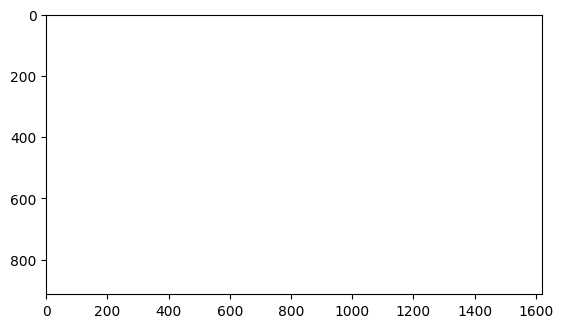

In [6]:
### CMYK
## No hay un convert prestablecido de CMYK en opencv por lo que podemos
## hacerlo con PIL
from PIL import Image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Leer imagen
img_cmyk = Image.open("/content/avatar.png")

# Ver modo original
print(img_cmyk.mode)

# Convertir explícitamente a CMYK
img_cmyk = img_cmyk.convert("CMYK")

# Pasar a numpy
img_cmyk = np.array(img_cmyk)

print(img_cmyk.shape)
print(img_cmyk.dtype)

#Mostrar imagen
plt.imshow(img_cmyk)
plt.show()

No se puede mostrar la imagen completa ya que plt.imshow() no interpreta imagenes de 4 canales.

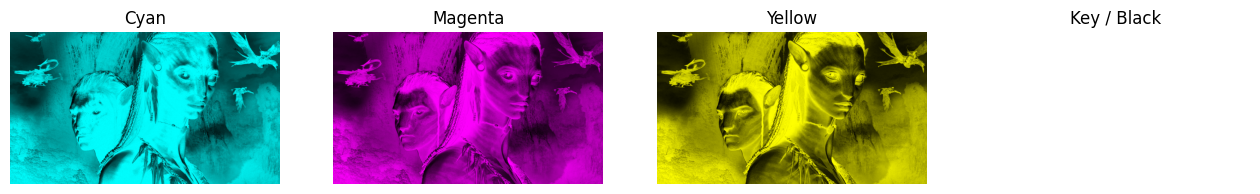

In [7]:
from matplotlib.colors import LinearSegmentedColormap

# Colormaps para cada canal
cmap_cyan = LinearSegmentedColormap.from_list("cyan", ["black", "cyan"])
cmap_magenta = LinearSegmentedColormap.from_list("magenta", ["black", "magenta"])
cmap_yellow = LinearSegmentedColormap.from_list("yellow", ["black", "yellow"])
cmap_black = LinearSegmentedColormap.from_list("black", ["white", "black"])

# Mostrar los canales
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

ax[0].imshow(img_cmyk[:, :, 0], cmap=cmap_cyan)
ax[0].set_title("Cyan")

ax[1].imshow(img_cmyk[:, :, 1], cmap=cmap_magenta)
ax[1].set_title("Magenta")

ax[2].imshow(img_cmyk[:, :, 2], cmap=cmap_yellow)
ax[2].set_title("Yellow")

ax[3].imshow(img_cmyk[:, :, 3], cmap=cmap_black)
ax[3].set_title("Key / Black")

for a in ax:
    a.axis("off")

plt.show()

### HSV/HSL

Estos modelos incluyen otros dos parámetros adicionales al matiz o croma para obtener el color, que son la saturación (en ambos) y el valor (en HSV) o la luminosidad o tono (en HSL). De ahí sus siglas: HSL (H – hue o matiz, S – saturation o saturación, L – luminosity o luminosidad/tono), HSV (idem excepto V de value o valor).

La diferencia entre HSV y HSL es que en HSV la saturación va del color puro al blanco, y en HSL la saturación va del color puro al gris medio, y el tono, en HSV va desde el negro al color, y en HSL va desde el negro al blanco. De ahí que HSL sea el que se utiliza más comúnmente en fotografía.

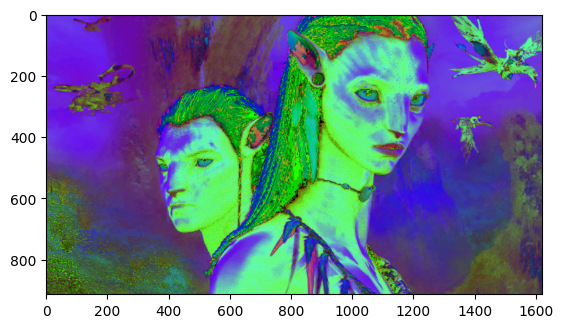

In [25]:
#### HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
plt.imshow(img_hsv, cmap='hsv')
plt.show()

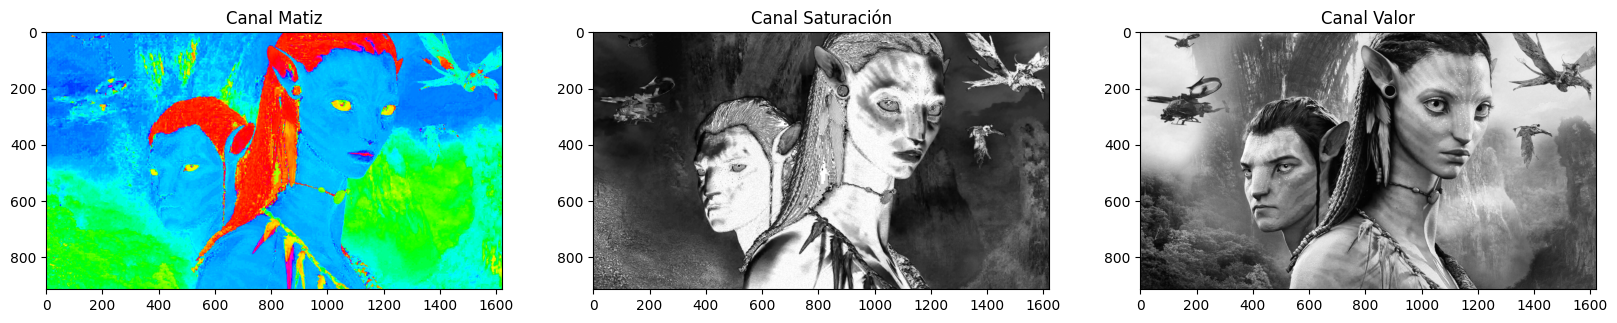

In [26]:
## Ver HSV por separado
fig, axs = plt.subplots(1, 3, figsize=(20, 15))
axs[0].imshow(img_hsv[:, :, 0], cmap='hsv')
axs[0].set_title('Canal Matiz')
axs[1].imshow(img_hsv[:, :, 1], cmap='gray')
axs[1].set_title('Canal Saturación')
axs[2].imshow(img_hsv[:, :, 2], cmap='gray')
axs[2].set_title('Canal Valor')
plt.show()


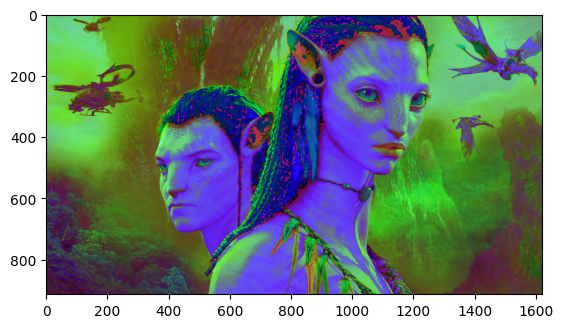

In [27]:
### HSL
img_hsl = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
plt.imshow(img_hsl)
plt.show()

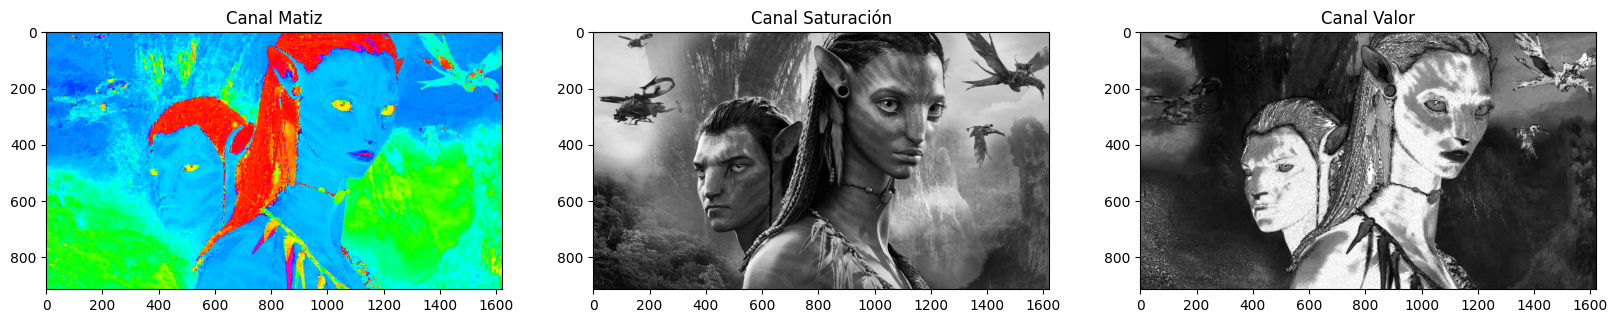

In [28]:
## Ver HSL por separado
fig, axs = plt.subplots(1,3, figsize=(20, 15))
axs[0].imshow(img_hsl[:, :, 0], cmap='hsv')
axs[0].set_title('Canal Matiz')
axs[1].imshow(img_hsl[:, :, 1], cmap='gray')
axs[1].set_title('Canal Saturación')
axs[2].imshow(img_hsl[:, :, 2], cmap='gray')
axs[2].set_title('Canal Valor')
plt.show()

Referencia: https://ahenav.wordpress.com/2014/04/09/modelos-de-color/

Saturación HSV VS HSL

La diferencia clave
- HSV → Saturación indica qué tan lejos está el color del gris en relación con el valor máximo del píxel.
- HSL → Saturación indica qué tan lejos está el color del gris en relación con la luminosidad del píxel.

## 3. Histogramas

Un histograma es un gráfico que muestra cómo se distribuyen los valores de una imagen. En una imagen, permite saber cuántos píxeles tienen cada nivel de intensidad, por ejemplo de 0 (negro) a 255 (blanco). Sirve para analizar características como brillo, contraste y distribución de colores; en una imagen CMYK se puede hacer un histograma para cada canal (Cyan, Magenta, Yellow y Black) para conocer la cantidad e intensidad de cada componente.

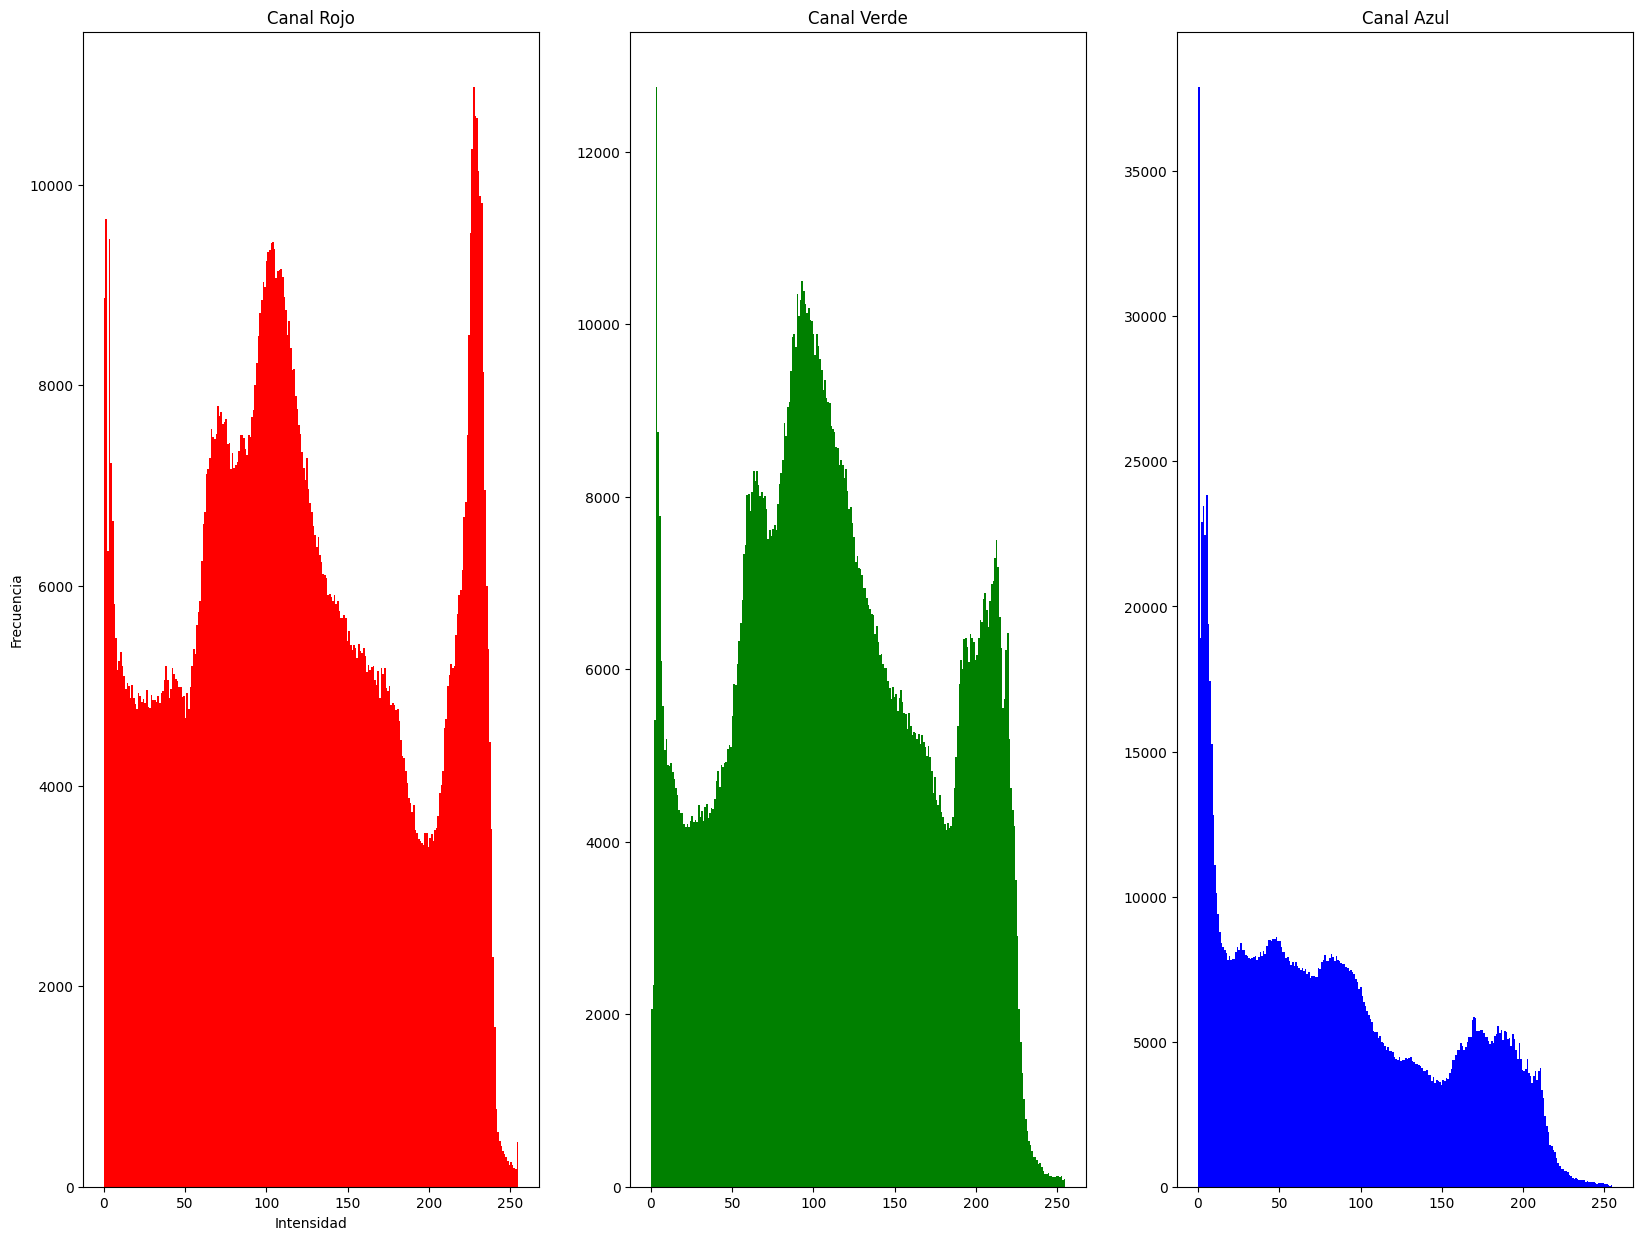

In [32]:
## Analisis de rgb en histograma
fig, axs = plt.subplots(1, 3, figsize=(20, 15))
axs[0].hist(img[:, :, 0].ravel(), bins=256, color='r')
axs[0].set_title('Canal Rojo')
axs[0].set_xlabel('Intensidad')
axs[0].set_ylabel('Frecuencia')
axs[1].hist(img[:, :, 1].ravel(), bins=256, color='g')
axs[1].set_title('Canal Verde')
axs[0].set_xlabel('Intensidad')
axs[0].set_ylabel('Frecuencia')
axs[2].hist(img[:, :, 2].ravel(), bins=256, color='b')
axs[2].set_title('Canal Azul')
axs[0].set_xlabel('Intensidad')
axs[0].set_ylabel('Frecuencia')

plt.show()


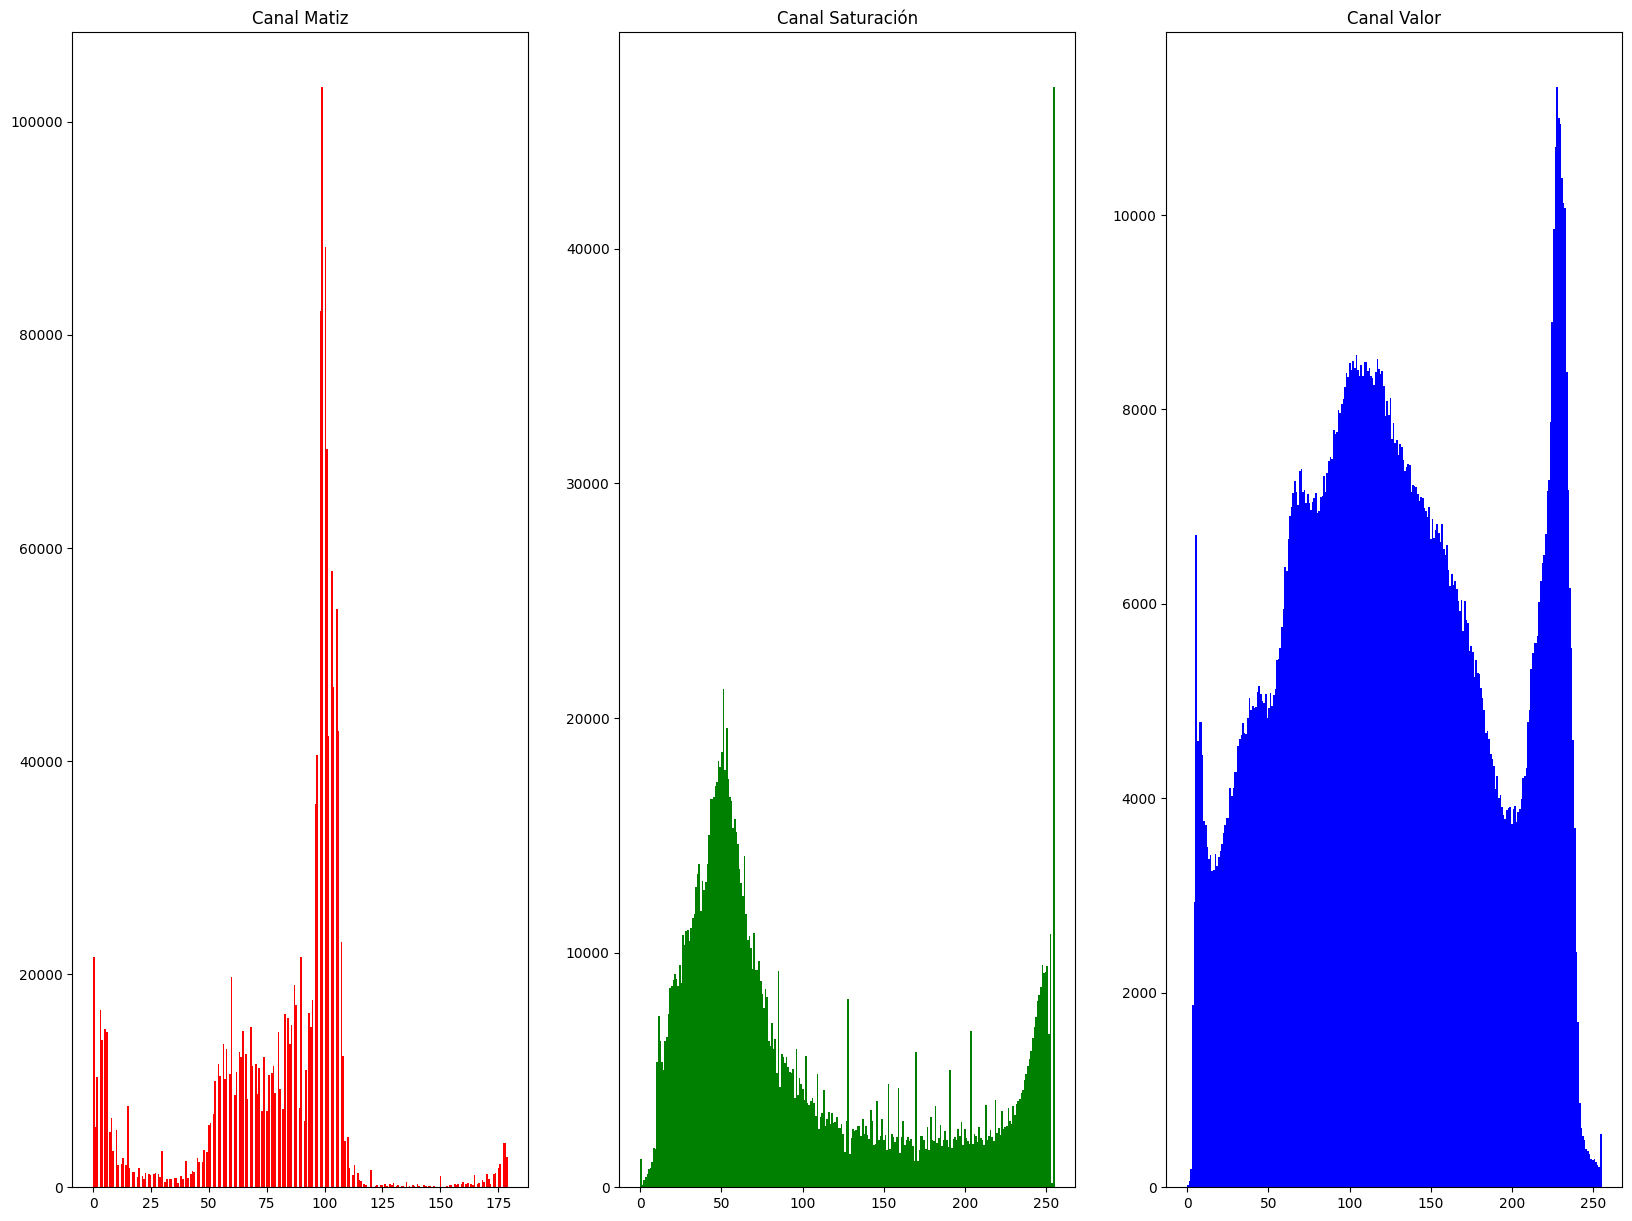

In [31]:
## Analisis HSV en histograma
fig, axs = plt.subplots(1, 3, figsize=(20, 15))
axs[0].hist(img_hsv[:, :, 0].ravel(), bins=256, color='r')
axs[0].set_title('Canal Matiz')
axs[1].hist(img_hsv[:, :, 1].ravel(), bins=256, color='g')
axs[1].set_title('Canal Saturación')
axs[2].hist(img_hsv[:, :, 2].ravel(), bins=256, color='b')
axs[2].set_title('Canal Valor')
plt.show()

Explicación:
- Matiz (Hue): presenta una concentración muy marcada alrededor de los valores 90–105, lo que indica que gran parte de los píxeles pertenece a tonalidades similares. También aparecen valores en otras zonas, pero con mucha menor frecuencia.
- Saturación (S): tiene una gran concentración cerca de 40–70 y otra muy importante cerca de 250–255. Esto indica que hay zonas con colores relativamente poco saturados y otras con colores muy intensos o puros.
- Valor (V): presenta una distribución bastante amplia, con muchos píxeles entre aproximadamente 50 y 200, además de un pico importante cerca de 225–240. Esto indica que la imagen contiene tanto zonas oscuras como zonas muy luminosas.

## 4. Convoluciones



> La convolución es una operación matemática que combina dos funciones para describir la superposición entre ambas. La convolución toma dos funciones, “desliza” una sobre la otra, multiplica los valores de las funciones en todos los puntos de superposición, y suma los productos para crear una nueva función. Este proceso crea una nueva función que representa cómo interactúan las dos funciones originales entre sí.
Formalmente, la convolución es una integral que expresa la cantidad de superposición de una función, *f(i)* cuando se desplaza sobre otra función *g(t)*, de este modo:



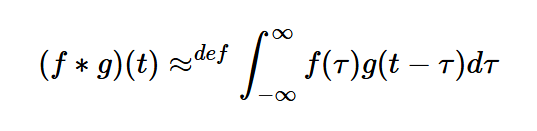

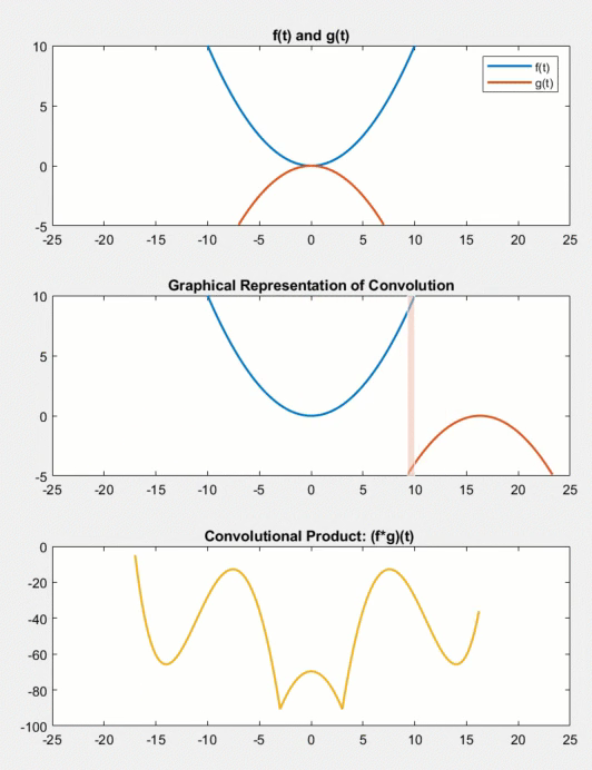

### Convolución en procesamiento de imágenes



> En el procesamiento de imágenes, el filtrado convolucional se puede utilizar para implementar algoritmos tales como detección de bordes, aumento de nitidez y desenfoque de imágenes.   
Esto se logra seleccionando el kernel apropiado (matriz de convolución).



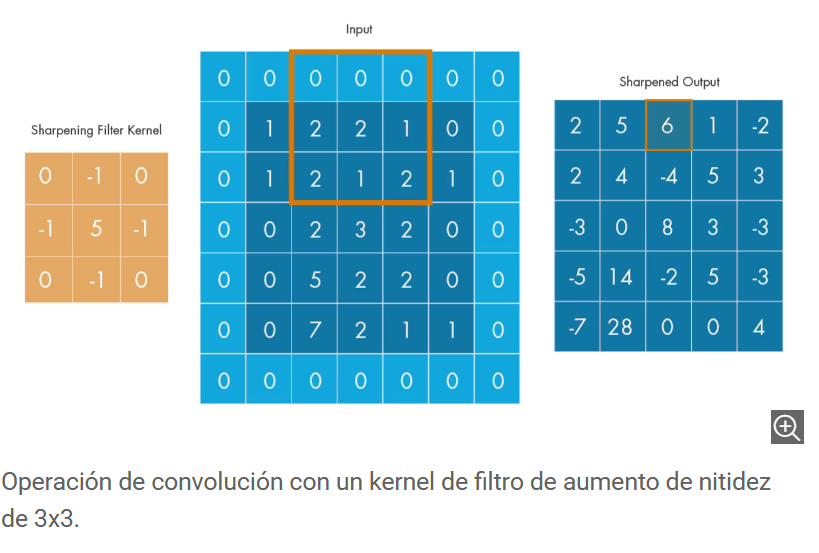

#### Filtros

Un filtro de nxn es una matriz algebraica que se utiliza para realizar una convolución sobre una imagen (otra matriz). De este manera, se busca obtener/resaltar x aspecto de la imagen.

Aplicación básica y manual de un filtro.
Aplicaremos el filtro de la imagen anterior para aumentar la nitidez de la imagen con la que venimos trabajando.

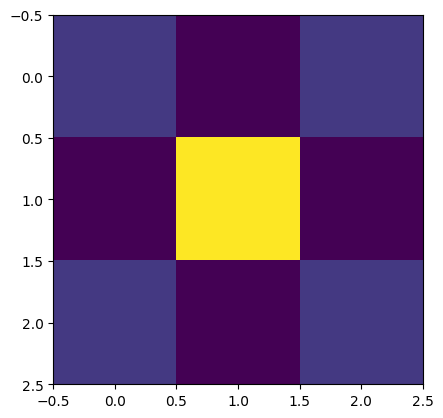

In [38]:
## definimos un kernel de 3x3
k = np.array([[0, -1, 0],
              [-1, 5, -1],
              [0, -1, 0]])

plt.imshow(k)

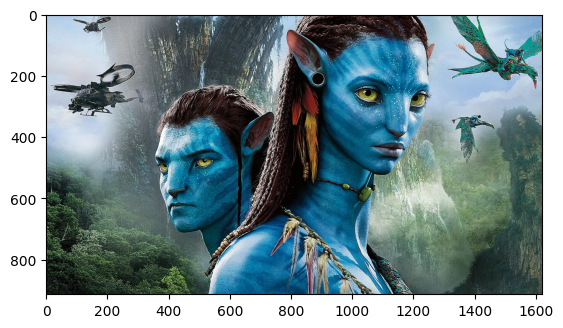

In [40]:
# Aplicamos el kernel a la imagen
img_conv = cv2.filter2D(img_rgb, -1, k)
plt.imshow(img_conv)

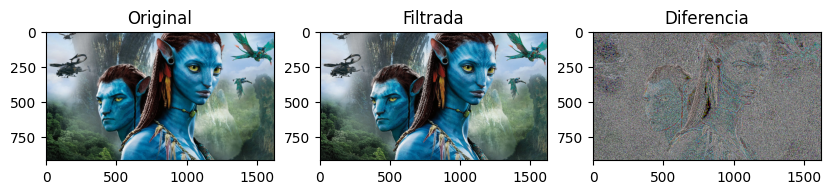

In [41]:
# Comparativa
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
ax[0].imshow(img_rgb)
ax[0].set_title('Original')
ax[1].imshow(img_conv)
ax[1].set_title('Filtrada')
ax[2].imshow((img_rgb - img_conv))
ax[2].set_title('Diferencia')
plt.show()
#

Veremos con mayor profundidad la aplicación de filtros para distitntos fines en la práctica tecnicas clásicas de visión.
